Lutas REALIZADO: 1022 | Período: 2016-2026
Decisivas: 1010 | Title fights: 70

[Q1] Spearman (year vs duration, non-title): rho=0.110, p=0.0007589, n=939

[Q2] Qui-quadrado pre/post-2020: chi2=20.45, p=0.0001369, V de Cramer=0.142, n=1009

[Q3] Classes analisadas: 10
                      n    mean   std  median
weight_class_clean                           
Heavyweight          80  190.12  5.80  190.50
Light Heavyweight   150  188.94  4.73  187.96
Middleweight        264  183.54  4.24  182.88
Welterweight        336  181.24  4.34  182.88
Lightweight         321  178.77  5.14  177.80
Catchweight         268  178.63  6.87  177.80
Featherweight       183  176.18  4.79  175.26
Bantamweight        125  169.98  4.48  170.18
Flyweight            44  166.43  4.01  167.64
Strawweight          35  162.49  3.17  162.56

[Q4] Resultados por classe:
            group   n  win_rate  ci_low  ci_high  p_value  p_adjusted  significant
      Lightweight 121    0.6281  0.5393   0.7090   0.0062      0.049

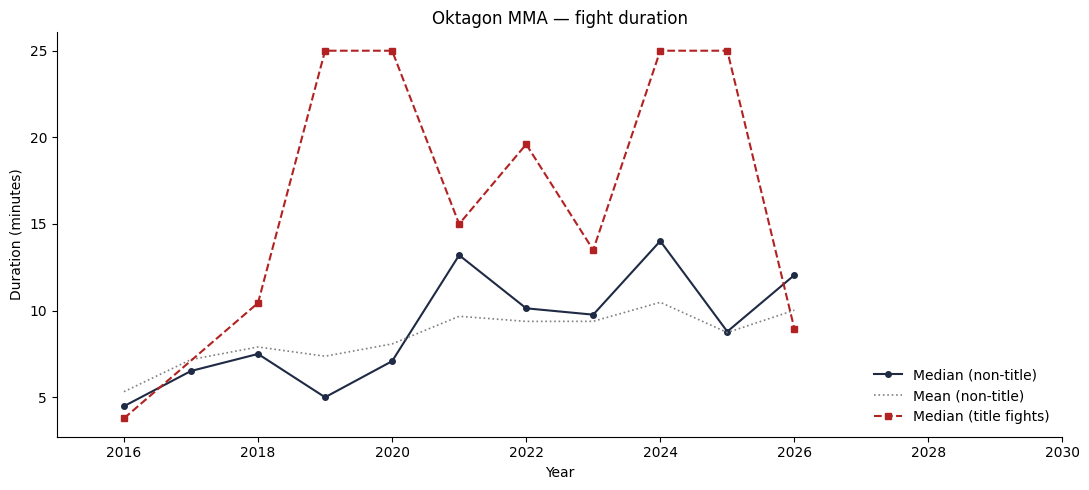

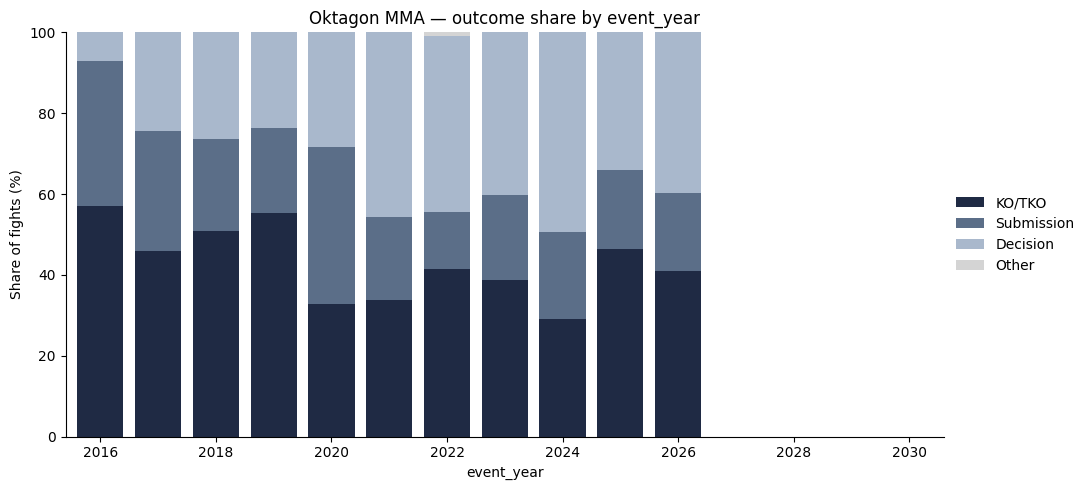

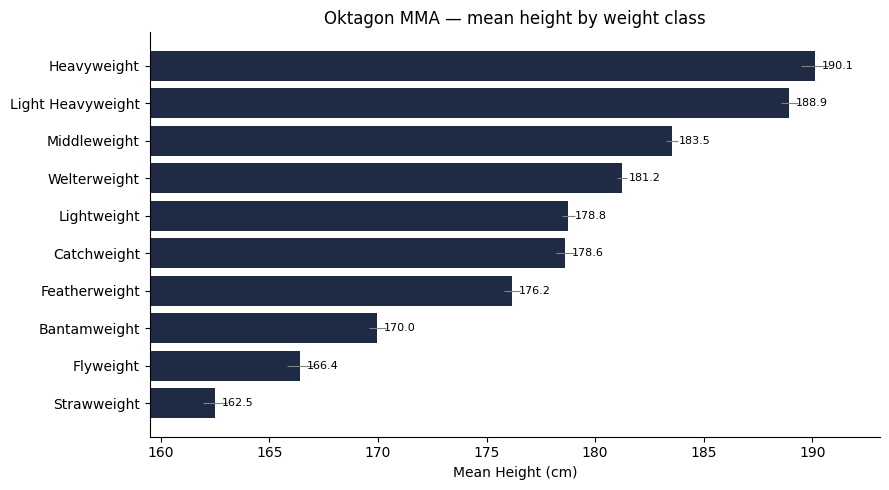

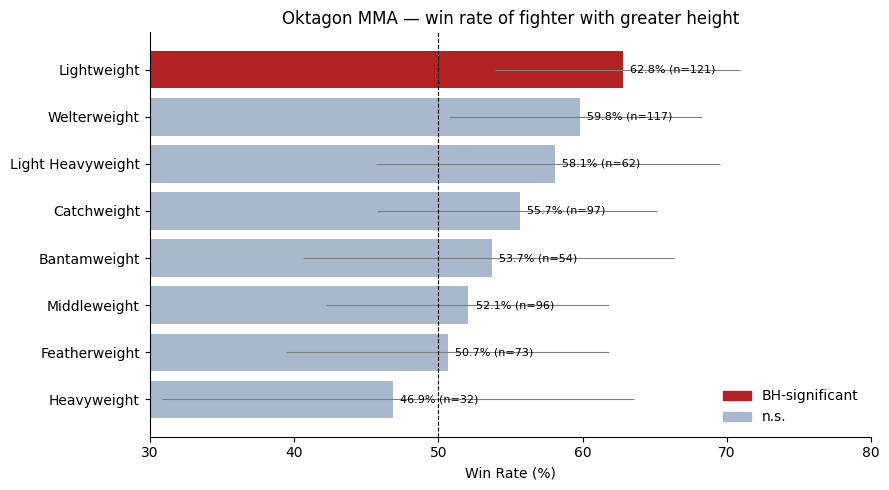

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


DATA_DIR = '/kaggle/input/datasets/leandroiber/oktagon-mma-dataset'
CSV_PATH = f'{DATA_DIR}/clean_sherdog_oktagon.csv'
JSON_PATH = f'{DATA_DIR}/oktagon_win_title_data.json'


def temporal_aggregation(df, time_col, value_col, group_col=None,
                         agg_funcs=('median', 'mean'), trend_test=True):
    funcs = list(agg_funcs) + ['count', 'std']
    if group_col is None:
        agg = df.groupby(time_col)[value_col].agg(funcs)
    else:
        agg = df.groupby([time_col, group_col])[value_col].agg(funcs).unstack()

    out = {'aggregation': agg}
    if trend_test:
        clean = df[[time_col, value_col]].dropna()
        if len(clean) > 3:
            rho, p = stats.spearmanr(clean[time_col], clean[value_col])
            out['spearman'] = {'rho': rho, 'p_value': p, 'n': len(clean)}
    return out


def categorical_composition_over_time(df, time_col, category_col,
                                      split_point=None, normalize=True):
    counts = df.groupby([time_col, category_col]).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) if normalize else counts

    out = {'proportions': proportions, 'counts': counts}

    if split_point is not None:
        before = df[df[time_col] < split_point][category_col].value_counts()
        after = df[df[time_col] >= split_point][category_col].value_counts()
        contingency = pd.DataFrame({'before': before, 'after': after}).fillna(0)
        chi2, p, dof, _ = stats.chi2_contingency(contingency)
        n = contingency.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        out['regime_test'] = {
            'chi2': chi2, 'p_value': p, 'dof': dof,
            'cramers_v': cramers_v, 'n': int(n),
            'contingency': contingency
        }
    return out


def group_descriptive(df, group_col, value_col, min_n=5):
    g = df.dropna(subset=[group_col, value_col]).groupby(group_col)[value_col]
    out = g.agg(['count', 'mean', 'std', 'median',
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.75)])
    out.columns = ['n', 'mean', 'std', 'median', 'q25', 'q75']
    out['iqr'] = out['q75'] - out['q25']
    out = out[out['n'] >= min_n]
    return out.sort_values('mean', ascending=False)


def paired_advantage_test(df, group_col, attr_a_col, attr_b_col,
                          winner_is_a_col=None,
                          min_n=30, mc_method='fdr_bh', alpha=0.05):
    results = []
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=[attr_a_col, attr_b_col]).copy()
        if winner_is_a_col is not None:
            sub = sub.dropna(subset=[winner_is_a_col])
            a_won = sub[winner_is_a_col].astype(bool)
        else:
            a_won = pd.Series(True, index=sub.index)

        sub = sub[sub[attr_a_col] != sub[attr_b_col]]
        a_won = a_won.loc[sub.index]
        n = len(sub)

        if n < min_n:
            results.append({'group': group, 'n': n, 'underpowered': True})
            continue

        a_greater = sub[attr_a_col] > sub[attr_b_col]
        greater_won = (a_greater & a_won) | (~a_greater & ~a_won)
        wins = int(greater_won.sum())

        ci_low, ci_high = stats.binomtest(wins, n).proportion_ci(method='wilson')
        p_value = stats.binomtest(wins, n, p=0.5, alternative='two-sided').pvalue

        results.append({
            'group': group, 'n': n, 'win_rate': wins / n,
            'ci_low': ci_low, 'ci_high': ci_high,
            'p_value': p_value, 'underpowered': False
        })

    res = pd.DataFrame(results)
    res['p_adjusted'] = np.nan
    res['significant'] = False
    res['underpowered'] = res['underpowered'].astype(bool)

    valid = ~res['underpowered']
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(res.loc[valid, 'p_value'],
                                       method=mc_method, alpha=alpha)
        res.loc[valid, 'p_adjusted'] = p_adj
        res.loc[valid, 'significant'] = p_adj < alpha
    return res.sort_values('win_rate', ascending=False, na_position='last')


def continuous_advantage_logit(df, group_col, diff_cols, target_col,
                               covariates=None, min_n=50):
    rows = []
    cols = list(diff_cols) + (covariates or [])
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=cols + [target_col])
        if len(sub) < min_n:
            continue
        X = sm.add_constant(sub[cols])
        y = sub[target_col].astype(int)
        try:
            m = sm.Logit(y, X).fit(disp=0)
            for c in cols:
                rows.append({
                    'group': group, 'predictor': c, 'n': len(sub),
                    'coef': m.params[c],
                    'odds_ratio': np.exp(m.params[c]),
                    'p_value': m.pvalues[c],
                    'or_ci_low': np.exp(m.conf_int().loc[c, 0]),
                    'or_ci_high': np.exp(m.conf_int().loc[c, 1]),
                    'pseudo_r2': m.prsquared
                })
        except Exception as e:
            rows.append({'group': group, 'error': str(e)})
    return pd.DataFrame(rows)


def load_oktagon():
    df = pd.read_csv(CSV_PATH)
    df = df[df['event_status'] == 'REALIZADO'].copy()
    df['event_date'] = pd.to_datetime(df['event_date'], utc=True, errors='coerce')
    df['event_year'] = df['event_date'].dt.year

    def time_to_min(row):
        try:
            m, s = map(int, str(row['time']).split(':'))
            r = int(row['round_num'])
            if r < 1:
                return np.nan
            return (r - 1) * 5 + m + s / 60
        except (ValueError, TypeError):
            return np.nan
    df['duration_min'] = df.apply(time_to_min, axis=1)

    def bucket_method(m):
        if pd.isna(m):
            return np.nan
        m = m.lower()
        if 'submission' in m:
            return 'Submission'
        if 'ko' in m or 'tko' in m:
            return 'KO/TKO'
        if 'decision' in m:
            return 'Decision'
        return 'Other'
    df['method_bucket'] = df['method'].apply(bucket_method)

    df['weight_class_clean'] = df['weight_class'].apply(
        lambda x: 'Catchweight' if pd.notna(x) and re.search(r'Catch', str(x), re.I) else x
    )

    df['decisive'] = df['fighter_1_result'] == 'win'

    with open(JSON_PATH) as f:
        title_data = json.load(f)
    title_map = {}
    for k, v in title_data.items():
        key = (v.get('event_date'), v.get('fighter_1'), v.get('fighter_2'))
        title_map[key] = v.get('is_title_fight', False)
    df['_date_str'] = df['event_date'].dt.strftime('%Y-%m-%d')
    df['is_title_fight'] = df.apply(
        lambda r: title_map.get((r['_date_str'], r['fighter_1'], r['fighter_2']), False),
        axis=1
    )
    df = df.drop(columns=['_date_str'])
    return df


def q1_duration_over_time(df, x_max=2030):
    non_title = df[~df['is_title_fight'] & df['decisive']]
    title = df[df['is_title_fight'] & df['decisive']]

    nt_res = temporal_aggregation(non_title, 'event_year', 'duration_min')
    t_res = temporal_aggregation(title, 'event_year', 'duration_min', trend_test=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    nt_agg = nt_res['aggregation']
    ax.plot(nt_agg.index, nt_agg['median'], '-o', color='#1f2a44',
            label='Median (non-title)', markersize=4)
    ax.plot(nt_agg.index, nt_agg['mean'], ':', color='gray',
            label='Mean (non-title)', linewidth=1.2)
    if len(t_res['aggregation']) > 0:
        t_agg = t_res['aggregation']
        ax.plot(t_agg.index, t_agg['median'], '--s', color='#b22222',
                label='Median (title fights)', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (minutes)')
    ax.set_title('Oktagon MMA — fight duration')
    ax.legend(loc='lower right', frameon=False)
    ax.set_xlim(df['event_year'].min() - 1, x_max)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, nt_res, t_res


def q2_outcome_share_over_time(df, split_year=2020, x_max=2030):
    decisive = df[df['decisive']].dropna(subset=['method_bucket'])
    res = categorical_composition_over_time(
        decisive, 'event_year', 'method_bucket', split_point=split_year
    )

    order = ['KO/TKO', 'Submission', 'Decision', 'Other']
    props = res['proportions'].reindex(columns=order, fill_value=0) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = {'KO/TKO': '#1f2a44', 'Submission': '#5b6e88',
               'Decision': '#a9b8cc', 'Other': '#d4d4d4'}
    bottom = np.zeros(len(props))
    for cat in order:
        ax.bar(props.index, props[cat], bottom=bottom, label=cat, color=palette[cat])
        bottom += props[cat].values
    ax.set_xlabel('event_year')
    ax.set_ylabel('Share of fights (%)')
    ax.set_title('Oktagon MMA — outcome share by event_year')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    ax.set_ylim(0, 100)
    ax.set_xlim(props.index.min() - 0.6, x_max + 0.6)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, res


def q3_height_by_weight_class(df, min_n=10):
    valid_classes = df['weight_class_clean'].value_counts()
    valid_classes = valid_classes[valid_classes >= min_n].index
    sub = df[df['weight_class_clean'].isin(valid_classes)]

    long = pd.concat([
        sub[['weight_class_clean', 'f1_height_cm']].rename(columns={'f1_height_cm': 'height'}),
        sub[['weight_class_clean', 'f2_height_cm']].rename(columns={'f2_height_cm': 'height'})
    ])
    desc = group_descriptive(long, 'weight_class_clean', 'height', min_n=min_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    desc_sorted = desc.sort_values('mean')
    ax.barh(desc_sorted.index, desc_sorted['mean'], color='#1f2a44',
            xerr=desc_sorted['std'] / np.sqrt(desc_sorted['n']),
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    for i, (idx, row) in enumerate(desc_sorted.iterrows()):
        ax.text(row['mean'] + 0.3, i, f"{row['mean']:.1f}",
                va='center', fontsize=8)
    ax.set_xlabel('Mean Height (cm)')
    ax.set_title('Oktagon MMA — mean height by weight class')
    ax.set_xlim(desc_sorted['mean'].min() - 3, desc_sorted['mean'].max() + 3)
    sns.despine()
    plt.tight_layout()
    return fig, desc


def q4_height_advantage(df, min_n=30):
    sub = df[df['decisive']].dropna(
        subset=['f1_height_cm', 'f2_height_cm', 'weight_class_clean']
    ).copy()
    valid_classes = sub['weight_class_clean'].value_counts()
    sub = sub[sub['weight_class_clean'].isin(valid_classes[valid_classes >= min_n].index)]

    sub['winner_is_f1'] = True
    res = paired_advantage_test(
        sub, group_col='weight_class_clean',
        attr_a_col='f1_height_cm', attr_b_col='f2_height_cm',
        winner_is_a_col='winner_is_f1', min_n=min_n
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    valid = res[~res['underpowered']].copy()
    valid = valid.sort_values('win_rate')
    colors = ['#b22222' if s else '#a9b8cc' for s in valid['significant']]
    ax.barh(valid['group'], valid['win_rate'] * 100, color=colors,
            xerr=[(valid['win_rate'] - valid['ci_low']) * 100,
                  (valid['ci_high'] - valid['win_rate']) * 100],
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    ax.axvline(50, ls='--', color='black', linewidth=0.8)
    for i, (_, row) in enumerate(valid.iterrows()):
        ax.text(row['win_rate'] * 100 + 0.5, i,
                f"{row['win_rate']*100:.1f}% (n={row['n']})",
                va='center', fontsize=8)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title('Oktagon MMA — win rate of fighter with greater height')
    ax.set_xlim(30, 80)
    handles = [plt.Rectangle((0, 0), 1, 1, color='#b22222'),
               plt.Rectangle((0, 0), 1, 1, color='#a9b8cc')]
    ax.legend(handles, ['BH-significant', 'n.s.'], loc='lower right', frameon=False)
    sns.despine()
    plt.tight_layout()
    return fig, res


if __name__ == '__main__':
    df = load_oktagon()
    print(f"Lutas REALIZADO: {len(df)} | Período: {df['event_year'].min()}-{df['event_year'].max()}")
    print(f"Decisivas: {df['decisive'].sum()} | Title fights: {df['is_title_fight'].sum()}")

    fig1, q1_nt, q1_t = q1_duration_over_time(df)
    fig1.savefig('q1_oktagon_duration.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q1] Spearman (year vs duration, non-title): "
          f"rho={q1_nt['spearman']['rho']:.3f}, "
          f"p={q1_nt['spearman']['p_value']:.4g}, "
          f"n={q1_nt['spearman']['n']}")

    fig2, q2 = q2_outcome_share_over_time(df, split_year=2020)
    fig2.savefig('q2_oktagon_outcomes.png', dpi=120, bbox_inches='tight')
    rt = q2['regime_test']
    print(f"\n[Q2] Qui-quadrado pre/post-2020: "
          f"chi2={rt['chi2']:.2f}, p={rt['p_value']:.4g}, "
          f"V de Cramer={rt['cramers_v']:.3f}, n={rt['n']}")

    fig3, q3 = q3_height_by_weight_class(df, min_n=10)
    fig3.savefig('q3_oktagon_height.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q3] Classes analisadas: {len(q3)}")
    print(q3[['n', 'mean', 'std', 'median']].round(2))

    fig4, q4 = q4_height_advantage(df, min_n=30)
    fig4.savefig('q4_oktagon_height_winrate.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q4] Resultados por classe:")
    cols_show = ['group', 'n', 'win_rate', 'ci_low', 'ci_high', 'p_value', 'p_adjusted', 'significant']
    print(q4[cols_show].round(4).to_string(index=False))

## Q1 > Fight Duration Over Time
The series shows a strong upward drift in fight duration across the 2016-2026 window. The non-title median starts at 4.5 minutes in 2016, climbs to roughly 7-8 minutes in 2017-2020, and reaches 10-14 minutes in 2021-2026. This is one of the steeper trends in the data, with the median nearly tripling over a ten-year span. The mean tracks the median closely throughout the period, confirming the shift is structural rather than driven by outliers.

Title fights (red dashed line, n = 70 across 10 years) sit far above the non-title series, with multiple years reaching the 25-minute regulation ceiling (2019, 2020, 2024, 2025). Title bouts at this promotion routinely go the full distance, which pushes the median to the cap. With an average of 7 title fights per year, the title series is less volatile than at promotions with sparser championship calendars, but individual years still oscillate widely between 9 and 25 minutes.

The combined picture is of a promotion that started in a finish-heavy regional phase and has rapidly converged toward a longer-duration profile, with title fights leading and non-title fights following.

## Q2 > Outcome Distribution Over Time
The outcome composition shows a statistically significant change across the pre/post-2020 split. The test returns χ² = 20.45, p = 0.000137, with Cramér's V = 0.142. The null hypothesis of no association between period and outcome composition is rejected, and the effect size sits in the small-to-moderate range. The shift is real and detectable despite the relatively short ten-year window.

Year-by-year visual composition tracks the shift clearly. The early period (2016-2019) is finish-dominated: KO/TKO accounts for 46-57% of decisive fights, submissions for 20-35%, and decisions for 7-26%. From 2020 onward, decisions climb sharply into the 28-49% range while submissions compress to roughly 15-22%. KO/TKO remains substantial across the entire series, sitting in the 29-51% range without a clear directional drift.
The pattern is consistent with promotional maturation: as the roster developed from early regional contracts into a more established competitive pool, matchups have produced fewer one-sided finishes and more time-limit outcomes. The KO/TKO baseline staying high (above 30% throughout the recent years) indicates that striking remains a primary finishing tool even as decisions become more common.

## Q3 > Mean Height by Weight Class
The ordinal progression is clean and well-behaved across all ten classes, with a proper gap between Heavyweight (190.1 cm, n = 80) and Light Heavyweight (188.9 cm, n = 150). The 1.2 cm separation at the top is in the expected range for adjacent divisions and indicates that the Heavyweight class has access to a real 190+ cm fighter pool rather than topping out at the Light Heavyweight ceiling.

The absolute height levels are at the upper end of what is typically observed in regional MMA rosters. This is a demographic effect: Czech, German, and broader Central European populations sit among the tallest in the world. Czech adult male mean stature is approximately 180-181 cm and German is approximately 179-180 cm, against a global mean closer to 171-173 cm. This baseline difference propagates into every weight class on the roster. The Heavyweight mean at 190.1 cm sits at the top of the data, and the middle divisions (Middleweight 183.5, Welterweight 181.2) reflect a roster whose physical baseline is structurally taller than rosters drawn from East Asian, Latin American, or globally mixed pools.

The Catchweight bucket (178.6 cm, n = 268) is one of the larger categories in the dataset and has the highest within-class standard deviation (6.87 cm vs 4 to 5 cm in the standard divisions). Catchweight is used extensively as a matchmaking instrument rather than as an exception, and the bucket aggregates fighters across a wide weight range. The mean lands just below Lightweight, which reflects the central tendency of the matched weights but masks an underlying multimodal distribution.

Flyweight (n = 44) and Strawweight (n = 35) sit at the lower end of the sample-size range and should be read with wider implicit confidence intervals than the larger divisions.

## Q4 > Win Rate by Height Advantage
Lightweight reaches statistical significance after correcting for multiple testing. The taller fighter wins 62.8% of the time (n = 121, raw p = 0.0062, adjusted p = 0.0492). The 95% confidence interval extends from 53.9% to 70.9%, with the lower bound clearly above the 50% baseline. This is a real, statistically supported height effect at the α = 0.05 level: in the Lightweight division, the taller fighter has a measurable advantage that does not reduce to sampling noise.

Welterweight sits just outside the corrected threshold at 59.8% (n = 117, raw p = 0.0415, adjusted p = 0.166). The raw p-value is below 0.05 but does not survive multiple-testing correction across the eight tested classes. The pattern across these two classes (155 to 170 lb range) is consistent: the middle-light divisions show a taller-fighter advantage that approaches or reaches significance once the sample is large enough to separate signal from noise.

The directional pattern across the remaining classes follows the same trend. Light Heavyweight (58.1%), Catchweight (55.7%), and Bantamweight (53.7%) sit above the baseline. Middleweight (52.1%) and Featherweight (50.7%) sit close to the baseline. Heavyweight is the only class with the shorter fighter winning more often at 46.9% (n = 32), which is unusual for the heaviest division. This is most plausibly a small-sample effect, since n = 32 is the lowest in the table and the 95% confidence interval (30.9% to 63.6%) is wide enough to include the baseline and substantial positive values.

The Catchweight result (55.7%, n = 97) is the only directional positive that should be discounted on structural grounds. When fighters are matched across a wide weight range, the height comparison is confounded by the weight asymmetry of the matched pair, and the height-advantage signal cannot be interpreted as conditional on weight.

Strawweight and Flyweight were excluded from the test due to insufficient sample after restricting to fights with both heights recorded (n < 30 in each).

The Lightweight finding is the strongest height-advantage signal in this dataset and is the most defensible candidate for further investigation, including a follow-up using continuous height differential as a predictor instead of the dichotomized taller-vs-shorter comparison.